## Customer Segmentation

`Customer Segmentation is an unsupervised machine learning problem where customers are grouped into meaningful segments based on similarities in their behavior and preferences`. Instead of treating every customer identically, segmentation helps a business understand different customer profiles and design personalized strategies for each group.

For this project, we use the MovieLens ml-latest-small dataset from GroupLens. It contains movie ratings, movie information, user-generated tags, and external movie identifiers across four CSV files: ratings.csv, movies.csv, tags.csv, and links.csv. The dataset contains approximately 100,836 ratings from 610 users across 9,742 movies.

### Project Objective

Identify hidden groups of movie users based on their engagement, rating behavior, and genre preferences, then translate those groups into actionable customer profiles.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_DIR = Path("../Datasets_MLmodels/ml-latest-small")
OUTPUT_DIR = Path("../outputs/recommendation/project08_customer_segmentation")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
movies = pd.read_csv(DATA_DIR / "movies.csv")
ratings = pd.read_csv(DATA_DIR / "ratings.csv")
tags = pd.read_csv(DATA_DIR / "tags.csv")
links = pd.read_csv(DATA_DIR / "links.csv")

In [4]:
print("Movies shape :", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape   :", tags.shape)
print("Links shape  :", links.shape)

Movies shape : (9742, 3)
Ratings shape: (100836, 4)
Tags shape   : (3683, 4)
Links shape  : (9742, 3)


In [5]:
print("MOVIES")
display(movies.head())

print("\nRATINGS")
display(ratings.head())

print("\nTAGS")
display(tags.head())

print("\nLINKS")
display(links.head())

MOVIES


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



RATINGS


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



TAGS


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200



LINKS


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [7]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [8]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-null   int64 
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 115.2+ KB


In [9]:
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB


In [10]:
print("Missing values in movies:")
display(movies.isnull().sum())

print("\nMissing values in ratings:")
display(ratings.isnull().sum())

print("\nMissing values in tags:")
display(tags.isnull().sum())

print("\nMissing values in links:")
display(links.isnull().sum())

Missing values in movies:


movieId    0
title      0
genres     0
dtype: int64


Missing values in ratings:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Missing values in tags:


userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


Missing values in links:


movieId    0
imdbId     0
tmdbId     8
dtype: int64

In [11]:
print("Duplicate rows in movies :", movies.duplicated().sum())
print("Duplicate rows in ratings:", ratings.duplicated().sum())
print("Duplicate rows in tags   :", tags.duplicated().sum())
print("Duplicate rows in links  :", links.duplicated().sum())

Duplicate rows in movies : 0
Duplicate rows in ratings: 0
Duplicate rows in tags   : 0
Duplicate rows in links  : 0


In [12]:
print("Unique users :", ratings["userId"].nunique())
print("Unique movies:", ratings["movieId"].nunique())

Unique users : 610
Unique movies: 9724


In [13]:
ratings["movieId"].isin(movies["movieId"]).mean()

np.float64(1.0)

In [14]:
tags["movieId"].isin(movies["movieId"]).mean()

np.float64(1.0)

In [15]:
links["movieId"].isin(movies["movieId"]).mean()

np.float64(1.0)

In [16]:
ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
tags["timestamp"] = pd.to_datetime(tags["timestamp"], unit="s")

In [17]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [18]:
ratings["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

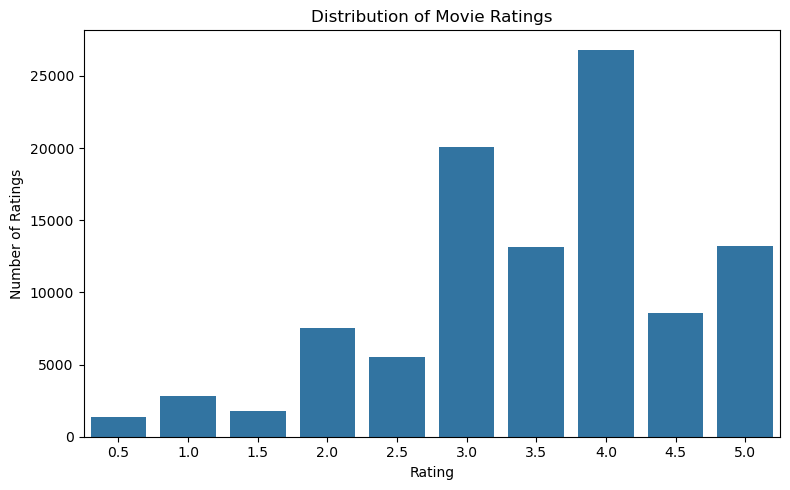

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=ratings,
    x="rating"
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
user_rating_count = (ratings.groupby("userId").size().reset_index(name="rating_count"))

user_rating_count.head()

,userId,rating_count
0,1,232
1,2,29
2,3,39
3,4,216
4,5,44


In [21]:
user_avg_rating = (ratings.groupby("userId")["rating"].mean().reset_index(name="avg_rating"))

user_avg_rating.head()

,userId,avg_rating
0,1,4.366379
1,2,3.948276
2,3,2.435897
3,4,3.555556
4,5,3.636364


In [22]:
user_rating_std = (ratings.groupby("userId")["rating"].std().reset_index(name="rating_std"))

user_rating_std.head()

,userId,rating_std
0,1,0.800048
1,2,0.805615
2,3,2.090642
3,4,1.314204
4,5,0.990441


In [23]:
user_unique_movies = (
    ratings
    .groupby("userId")["movieId"]
    .nunique()
    .reset_index(name="unique_movies")
)

user_unique_movies.head()

,userId,unique_movies
0,1,232
1,2,29
2,3,39
3,4,216
4,5,44


In [24]:
ratings_movies = ratings.merge(
    movies,
    on="movieId",
    how="left"
)
ratings_movies.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [25]:
genre_dummies = (
    ratings_movies["genres"]
    .str.get_dummies(sep="|")
)
genre_dummies.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0


In [26]:
user_genres = pd.concat(
    [
        ratings_movies[["userId"]],
        genre_dummies
    ],
    axis=1
)
user_genre_counts = (
    user_genres
    .groupby("userId")
    .sum()
)

user_genre_counts.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
1,0,90,85,29,42,83,45,0,68,47,1,17,0,22,18,26,40,55,22,7
2,0,11,3,0,0,7,10,3,17,0,0,1,4,0,2,1,4,10,1,1
3,0,14,11,4,5,9,2,0,16,4,0,8,0,1,1,5,15,7,5,0
4,0,25,29,6,10,104,27,2,120,19,4,4,1,16,23,58,12,38,7,10
5,0,9,8,6,9,15,12,0,25,7,0,1,3,5,1,11,2,9,3,2


In [27]:
user_genre_preferences = (
    user_genre_counts
    .div(
        user_genre_counts.sum(axis=1),
        axis=0
    )
)
user_genre_preferences.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
1,0.0,0.129125,0.121951,0.041607,0.060258,0.119082,0.064562,0.000000,0.097561,0.067432,0.001435,0.024390,0.000000,0.031564,0.025825,0.037303,0.057389,0.078910,0.031564,0.010043
2,0.0,0.146667,0.040000,0.000000,0.000000,0.093333,0.133333,0.040000,0.226667,0.000000,0.000000,0.013333,0.053333,0.000000,0.026667,0.013333,0.053333,0.133333,0.013333,0.013333
3,0.0,0.130841,0.102804,0.037383,0.046729,0.084112,0.018692,0.000000,0.149533,0.037383,0.000000,0.074766,0.000000,0.009346,0.009346,0.046729,0.140187,0.065421,0.046729,0.000000
4,0.0,0.048544,0.056311,0.011650,0.019417,0.201942,0.052427,0.003883,0.233010,0.036893,0.007767,0.007767,0.001942,0.031068,0.044660,0.112621,0.023301,0.073786,0.013592,0.019417
5,0.0,0.070312,0.062500,0.046875,0.070312,0.117188,0.093750,0.000000,0.195312,0.054688,0.000000,0.007812,0.023438,0.039062,0.007812,0.085938,0.015625,0.070312,0.023438,0.015625


In [28]:
user_tag_count = (
    tags
    .groupby("userId")
    .size()
    .reset_index(name="tag_count")
)

user_tag_count.head()

,userId,tag_count
0,2,9
1,7,1
2,18,16
3,21,4
4,49,3


In [29]:
user_features = user_rating_count.copy()

user_features = user_features.merge(user_avg_rating, on="userId", how="left")
user_features = user_features.merge(
    user_rating_std,
    on="userId",
    how="left"
)
user_features = user_features.merge(user_unique_movies, on="userId", how="left")
user_features = user_features.merge(
    user_tag_count,
    on="userId",
    how="left"
)
user_features = user_features.merge(user_genre_preferences.reset_index(), on="userId", how="left")

user_features.head()

,userId,rating_count,avg_rating,rating_std,unique_movies,tag_count,(no genres listed),Action,Adventure,Animation,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,232,4.366379,0.800048,232,NaN,0.0,0.129125,0.121951,0.041607,...,0.001435,0.024390,0.000000,0.031564,0.025825,0.037303,0.057389,0.078910,0.031564,0.010043
1,2,29,3.948276,0.805615,29,9.0,0.0,0.146667,0.040000,0.000000,...,0.000000,0.013333,0.053333,0.000000,0.026667,0.013333,0.053333,0.133333,0.013333,0.013333
2,3,39,2.435897,2.090642,39,NaN,0.0,0.130841,0.102804,0.037383,...,0.000000,0.074766,0.000000,0.009346,0.009346,0.046729,0.140187,0.065421,0.046729,0.000000
3,4,216,3.555556,1.314204,216,NaN,0.0,0.048544,0.056311,0.011650,...,0.007767,0.007767,0.001942,0.031068,0.044660,0.112621,0.023301,0.073786,0.013592,0.019417
4,5,44,3.636364,0.990441,44,NaN,0.0,0.070312,0.062500,0.046875,...,0.000000,0.007812,0.023438,0.039062,0.007812,0.085938,0.015625,0.070312,0.023438,0.015625


In [30]:
user_features.shape

(610, 26)

In [31]:
user_features.isnull().sum()

userId                  0
rating_count            0
avg_rating              0
rating_std              0
unique_movies           0
tag_count             552
(no genres listed)      0
Action                  0
Adventure               0
Animation               0
Children                0
Comedy                  0
Crime                   0
Documentary             0
Drama                   0
Fantasy                 0
Film-Noir               0
Horror                  0
IMAX                    0
Musical                 0
Mystery                 0
Romance                 0
Sci-Fi                  0
Thriller                0
War                     0
Western                 0
dtype: int64

In [32]:
user_features["tag_count"] = (user_features["tag_count"].fillna(0))
user_features.isnull().sum()

userId                0
rating_count          0
avg_rating            0
rating_std            0
unique_movies         0
tag_count             0
(no genres listed)    0
Action                0
Adventure             0
Animation             0
Children              0
Comedy                0
Crime                 0
Documentary           0
Drama                 0
Fantasy               0
Film-Noir             0
Horror                0
IMAX                  0
Musical               0
Mystery               0
Romance               0
Sci-Fi                0
Thriller              0
War                   0
Western               0
dtype: int64

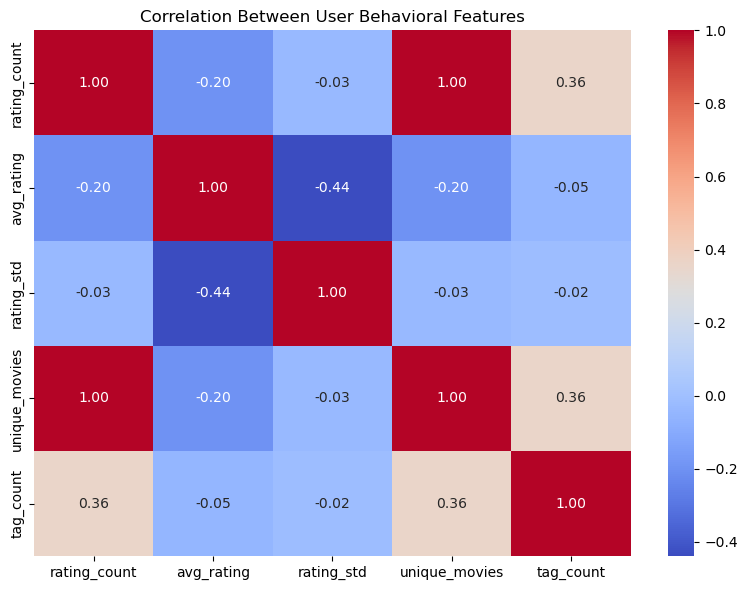

In [33]:
behavior_features = [
    "rating_count",
    "avg_rating",
    "rating_std",
    "unique_movies",
    "tag_count"
]
plt.figure(figsize=(8, 6))

sns.heatmap(
    user_features[behavior_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between User Behavioral Features")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "behavior_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
genre_columns = list(
    user_genre_preferences.columns
)
clustering_columns = (
    behavior_features +
    genre_columns
)
X = user_features[clustering_columns].copy()
X.shape

(610, 25)

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K_range = range(2, 11)
inertia = []
for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

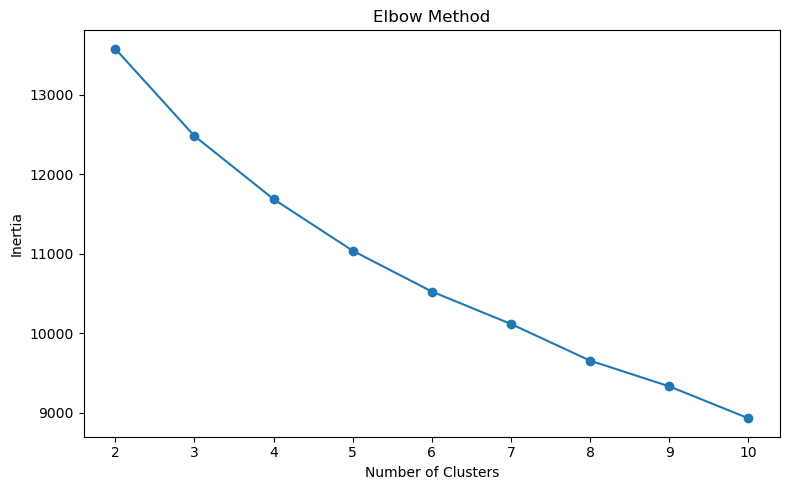

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.xticks(list(K_range))

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
silhouette_scores = []
for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels
    )
    silhouette_scores.append(score)

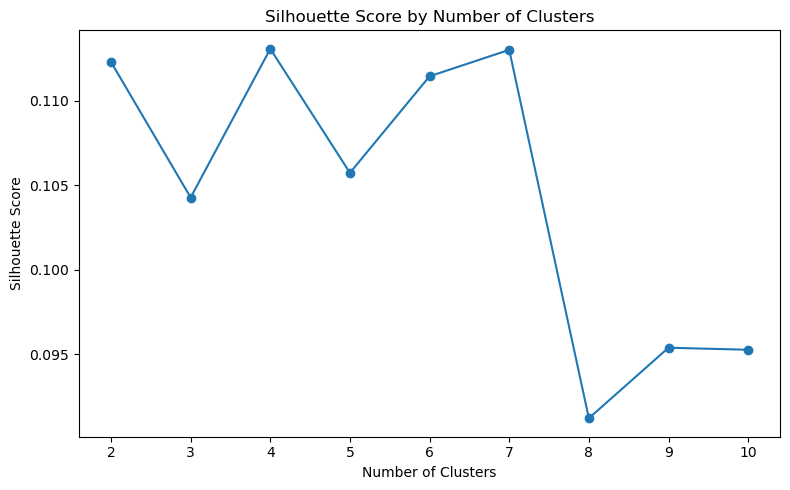

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.xticks(list(K_range))

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
cluster_evaluation = pd.DataFrame({
    "k": list(K_range),
    "inertia": inertia,
    "silhouette_score": silhouette_scores
})

cluster_evaluation

,k,inertia,silhouette_score
0,2,13578.906274,0.112295
1,3,12482.408414,0.104277
2,4,11688.310513,0.113072
3,5,11039.256214,0.105738
4,6,10525.978361,0.111447
5,7,10118.035728,0.113010
6,8,9657.015711,0.091224
7,9,9333.713997,0.095395
8,10,8932.388602,0.095274


In [40]:
optimal_k = (
    cluster_evaluation
    .loc[cluster_evaluation["silhouette_score"].idxmax(), "k"]
)
optimal_k = int(optimal_k)
print("Selected number of clusters:", optimal_k)

Selected number of clusters: 4


In [41]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
user_features["cluster"] = (kmeans.fit_predict(X_scaled))
user_features.head()

,userId,rating_count,avg_rating,rating_std,unique_movies,tag_count,(no genres listed),Action,Adventure,Animation,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,cluster
0,1,232,4.366379,0.800048,232,0.0,0.0,0.129125,0.121951,0.041607,...,0.024390,0.000000,0.031564,0.025825,0.037303,0.057389,0.078910,0.031564,0.010043,3
1,2,29,3.948276,0.805615,29,9.0,0.0,0.146667,0.040000,0.000000,...,0.013333,0.053333,0.000000,0.026667,0.013333,0.053333,0.133333,0.013333,0.013333,1
2,3,39,2.435897,2.090642,39,0.0,0.0,0.130841,0.102804,0.037383,...,0.074766,0.000000,0.009346,0.009346,0.046729,0.140187,0.065421,0.046729,0.000000,3
3,4,216,3.555556,1.314204,216,0.0,0.0,0.048544,0.056311,0.011650,...,0.007767,0.001942,0.031068,0.044660,0.112621,0.023301,0.073786,0.013592,0.019417,1
4,5,44,3.636364,0.990441,44,0.0,0.0,0.070312,0.062500,0.046875,...,0.007812,0.023438,0.039062,0.007812,0.085938,0.015625,0.070312,0.023438,0.015625,0


In [42]:
final_silhouette = silhouette_score(
    X_scaled,
    user_features["cluster"]
)
print(f"Final Silhouette Score: {final_silhouette:.4f}")

Final Silhouette Score: 0.1131


In [43]:
cluster_sizes = (
    user_features["cluster"]
    .value_counts()
    .sort_index()
)
cluster_sizes

cluster
0    143
1    207
2     36
3    224
Name: count, dtype: int64

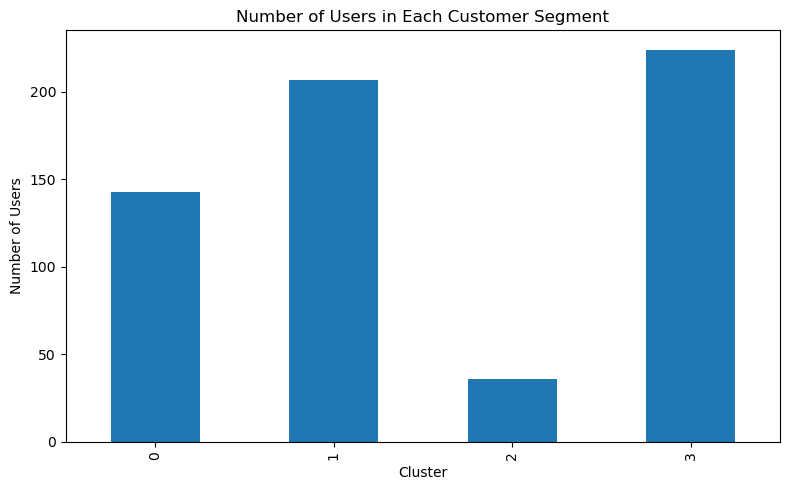

In [44]:
plt.figure(figsize=(8, 5))

cluster_sizes.plot(
    kind="bar"
)

plt.title("Number of Users in Each Customer Segment")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "cluster_sizes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
segment_profiles = (
    user_features
    .groupby("cluster")[clustering_columns]
    .mean()
)
segment_profiles["user_count"] = (
    user_features
    .groupby("cluster")
    .size()
)
segment_profiles

,rating_count,avg_rating,rating_std,unique_movies,tag_count,(no genres listed),Action,Adventure,Animation,Children,...,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,user_count
cluster,,,,,,,,,,,,,,,,,,,,,
0,120.692308,3.568623,0.986302,120.692308,0.538462,0.000089,0.081965,0.092223,0.042918,0.060074,...,0.018274,0.013757,0.030414,0.018530,0.095065,0.046441,0.064461,0.012898,0.007498,143
1,109.420290,3.668915,0.923314,109.420290,1.531401,0.000000,0.093235,0.061025,0.011716,0.017672,...,0.022135,0.008904,0.008843,0.036886,0.079261,0.043250,0.114941,0.028524,0.009550,207
2,986.000000,3.238601,0.936335,986.000000,72.194444,0.000332,0.104833,0.080232,0.025547,0.032473,...,0.046468,0.012566,0.014955,0.028283,0.063501,0.062988,0.096407,0.013965,0.006464,36
3,113.531250,3.770257,0.891363,113.531250,3.080357,0.000173,0.151405,0.117958,0.023499,0.028420,...,0.023766,0.022802,0.009525,0.025309,0.044838,0.087782,0.110227,0.019573,0.006488,224


In [46]:
cluster_behavior = (user_features.groupby("cluster")[behavior_features].mean())

cluster_behavior

,rating_count,avg_rating,rating_std,unique_movies,tag_count
cluster,,,,,
0,120.692308,3.568623,0.986302,120.692308,0.538462
1,109.420290,3.668915,0.923314,109.420290,1.531401
2,986.000000,3.238601,0.936335,986.000000,72.194444
3,113.531250,3.770257,0.891363,113.531250,3.080357


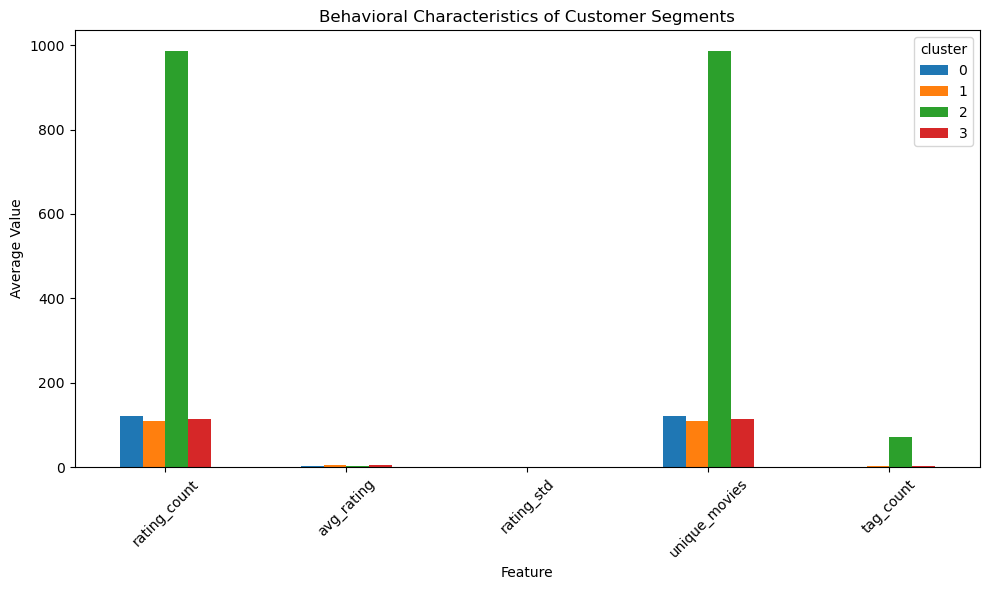

In [47]:
cluster_behavior.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Behavioral Characteristics of Customer Segments")
plt.xlabel("Feature")
plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "cluster_behavior.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
dominant_genres = (user_genre_preferences
    .groupby(
        user_features["cluster"]
    )
    .mean()
)

In [49]:
for cluster in dominant_genres.index:

    top_genres = (
        dominant_genres.loc[cluster]
        .sort_values(ascending=False)
        .head(3)
    )

    print(f"\nCluster {cluster}")
    print(top_genres)


Cluster 0.0
Drama     0.154941
Comedy    0.132053
Action    0.115379
Name: 0.0, dtype: float64

Cluster 1.0
Drama     0.158216
Comedy    0.135544
Action    0.109060
Name: 1.0, dtype: float64

Cluster 2.0
Drama     0.162042
Comedy    0.140757
Action    0.108829
Name: 2.0, dtype: float64

Cluster 3.0
Drama     0.158870
Comedy    0.127008
Action    0.114698
Name: 3.0, dtype: float64


In [50]:
segment_summary = []

for cluster in sorted(user_features["cluster"].unique()):

    cluster_data = user_features[
        user_features["cluster"] == cluster
    ]

    top_genres = (
        cluster_data[genre_columns]
        .mean()
        .sort_values(ascending=False)
        .head(3)
        .index
        .tolist()
    )

    segment_summary.append({
        "cluster": cluster,
        "users": len(cluster_data),
        "avg_ratings_per_user": cluster_data["rating_count"].mean(),
        "avg_user_rating": cluster_data["avg_rating"].mean(),
        "avg_unique_movies": cluster_data["unique_movies"].mean(),
        "avg_tag_count": cluster_data["tag_count"].mean(),
        "top_genres": ", ".join(top_genres)
    })

segment_summary = pd.DataFrame(segment_summary)

segment_summary

,cluster,users,avg_ratings_per_user,avg_user_rating,avg_unique_movies,avg_tag_count,top_genres
0,0,143,120.692308,3.568623,120.692308,0.538462,"Comedy, Drama, Romance"
1,1,207,109.420290,3.668915,109.420290,1.531401,"Drama, Comedy, Thriller"
2,2,36,986.000000,3.238601,986.000000,72.194444,"Comedy, Drama, Action"
3,3,224,113.531250,3.770257,113.531250,3.080357,"Action, Drama, Adventure"


In [51]:
user_features.to_csv(
    OUTPUT_DIR / "user_segments.csv",
    index=False
)
segment_profiles.to_csv(
    OUTPUT_DIR / "segment_profiles.csv"
)
cluster_evaluation.to_csv(
    OUTPUT_DIR / "cluster_evaluation.csv",
    index=False
)
segment_summary.to_csv(
    OUTPUT_DIR / "segment_summary.csv",
    index=False
)

In [52]:
print("Project 8 outputs created:\n")

for file in OUTPUT_DIR.iterdir():

    if file.is_file():
        print(file.name)

print("\nFigures created:")

for file in FIGURE_DIR.iterdir():
    print(file.name)

Project 8 outputs created:

cluster_evaluation.csv
segment_profiles.csv
segment_summary.csv
user_segments.csv

Figures created:
behavior_correlation.png
cluster_behavior.png
cluster_sizes.png
elbow_curve.png
rating_distribution.png
silhouette_scores.png
